In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [5]:
FILE_NAME = 'colorado_motor_vehicle_sales.csv'
data = pd.read_csv(FILE_NAME)

In [41]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Year     501 non-null    int64         
 1   Quarter  501 non-null    int64         
 2   County   501 non-null    object        
 3   Sales    501 non-null    int64         
 4   Month    501 non-null    int64         
 5   Date     501 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 23.6+ KB
None


In [20]:
data.rename(columns={'sales': 'Sales'}, inplace=True)
data.rename(columns={'year': 'Year', 'quarter': 'Quarter', 'county': 'County'}, inplace=True)

In [21]:
print(data.head())


   Year  Quarter              County      Sales
0  2008        1               Adams  231609000
1  2008        1            Arapahoe  550378000
2  2008        1  Boulder/Broomfield  176771000
3  2008        1              Denver  200103000
4  2008        1             Douglas   93259000


In [22]:

print("\n--- Missing Values Check ---")
print(data.isnull().sum())



--- Missing Values Check ---
Year       0
Quarter    0
County     0
Sales      0
dtype: int64


In [23]:
data.dropna(inplace=True)

In [42]:
print("\n--- Descriptive Statistics for Sales ---")
# Use the 'id' format to display large numbers cleanly
print(data['Sales'].describe().apply(lambda x: f"{x:,.0f}"))


--- Descriptive Statistics for Sales ---
count            501
mean     176,058,483
std      164,205,510
min        6,274,000
25%       61,482,000
50%      138,582,000
75%      224,158,000
max      916,910,000
Name: Sales, dtype: object


In [32]:
def get_quarter_end_month(quarter):
    # Q1: March (03), Q2: June (06), Q3: September (09), Q4: December (12)
    return {1: 3, 2: 6, 3: 9, 4: 12}.get(quarter)


In [33]:
data['Month'] = data['Quarter'].apply(get_quarter_end_month)

In [34]:
print(data[['Year', 'Quarter', 'Month']].head())


   Year  Quarter  Month
0  2008        1      3
1  2008        1      3
2  2008        1      3
3  2008        1      3
4  2008        1      3


In [36]:
data['Date'] = pd.to_datetime(
    data['Year'].astype(str) + '-' + data['Month'].astype(str) + '-01'
) + pd.offsets.MonthEnd(0)


In [39]:
time_series_data = data.groupby('Date')['Sales'].sum()
monthly_sales = time_series_data.resample('Q').sum()

/tmp/ipython-input-1559858994.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  monthly_sales = time_series_data.resample('Q').sum()


In [40]:
print("\n--- Aggregated Quarterly Sales Head ---")
print(monthly_sales.head())



--- Aggregated Quarterly Sales Head ---
Date
2008-03-31    2407552000
2008-06-30    2427936000
2008-09-30    2300541000
2008-12-31    1829532000
2009-03-31    1657155000
Freq: QE-DEC, Name: Sales, dtype: int64


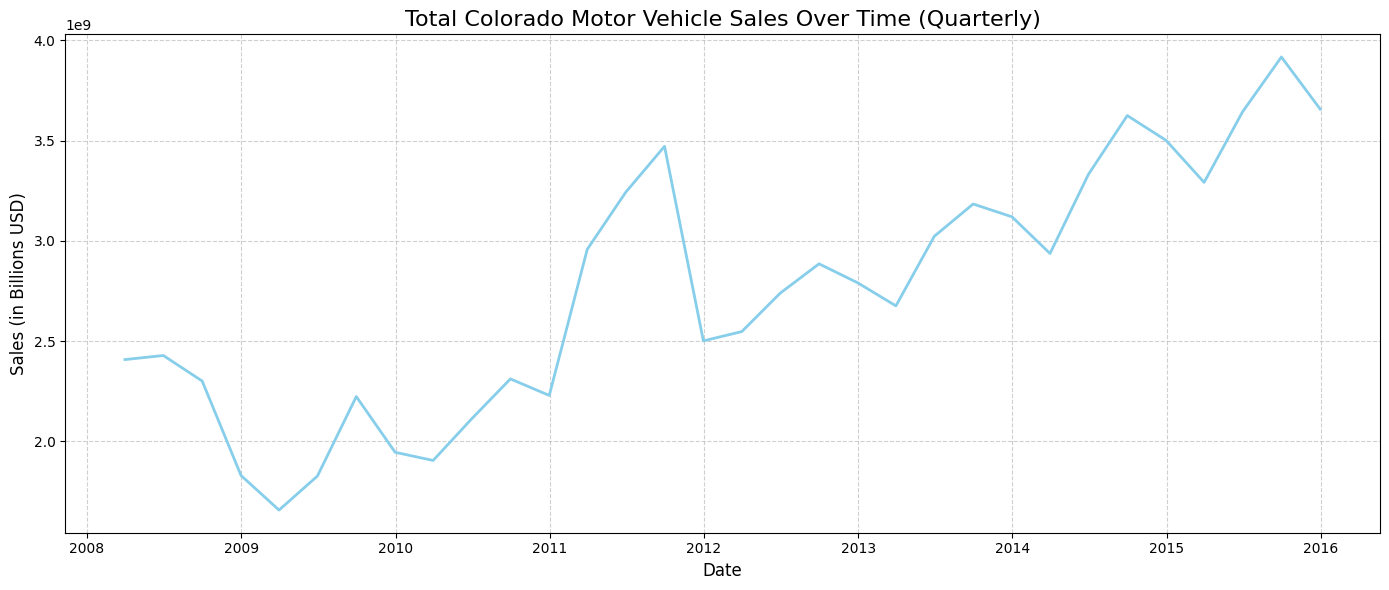

In [52]:
# --- Visualization 1: Sales Trend Over Time (Aggregate) ---
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Total Sales', color='skyblue', linewidth=2)
plt.title('Total Colorado Motor Vehicle Sales Over Time (Quarterly)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (in Billions USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


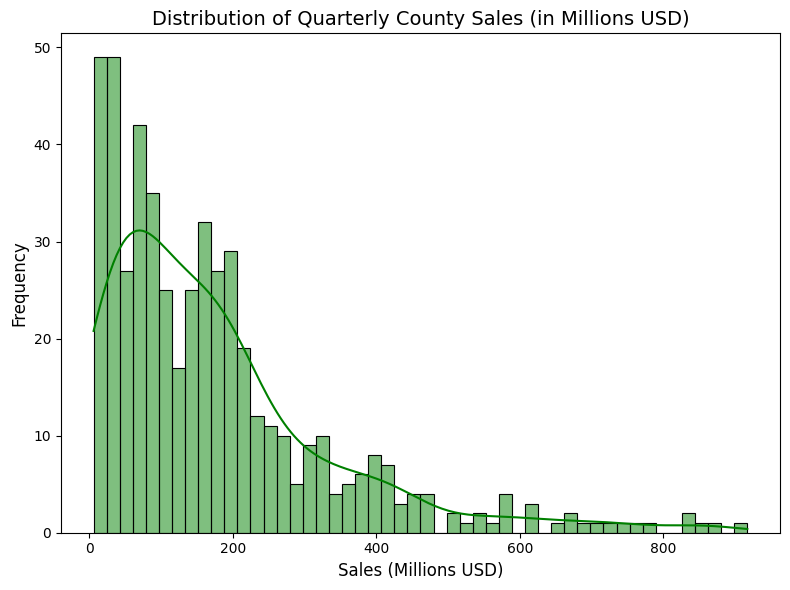

In [44]:
# --- Visualization 2: Sales Distribution ---
plt.figure(figsize=(8, 6))
sns.histplot(data['Sales'] / 1e6, bins=50, kde=True, color='green')
plt.title('Distribution of Quarterly County Sales (in Millions USD)', fontsize=14)
plt.xlabel('Sales (Millions USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1582687981.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_counties.index, y=top_10_counties.values, palette='viridis')


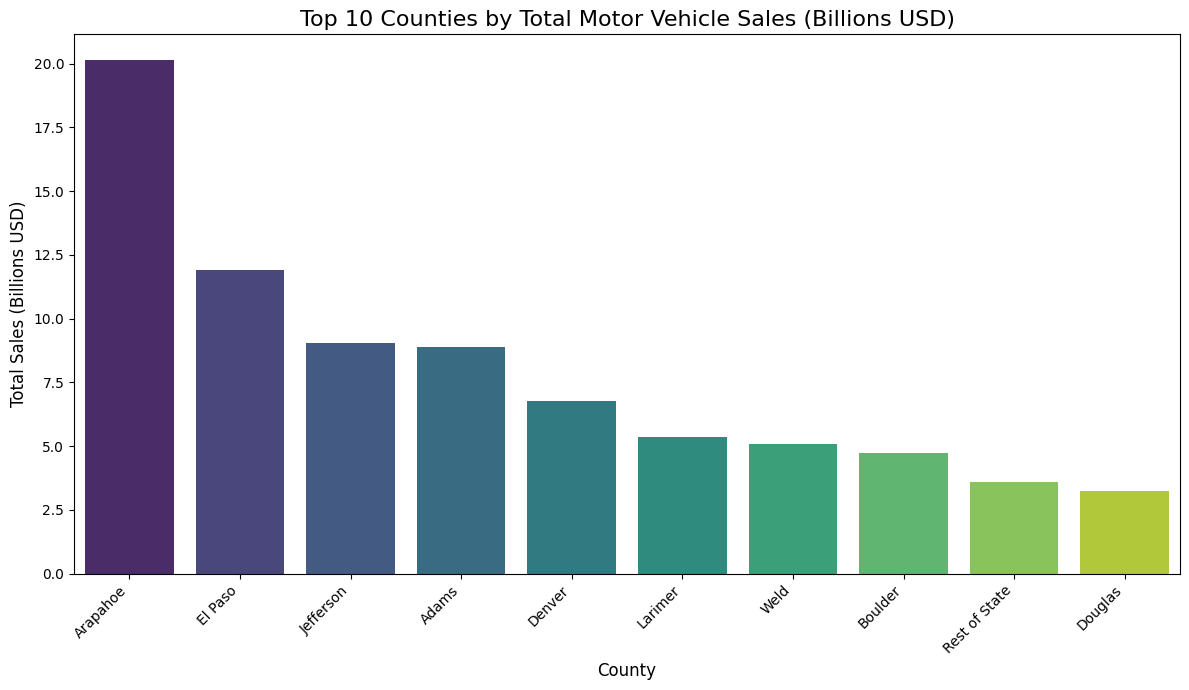

In [47]:
# --- Visualization 3: Sales by County (Top 10) ---
# Group by county and calculate total sales
county_sales = data.groupby('County')['Sales'].sum().sort_values(ascending=False)
top_10_counties = county_sales.head(10) / 1e9 # Convert to Billions

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_counties.index, y=top_10_counties.values, palette='viridis')
plt.title('Top 10 Counties by Total Motor Vehicle Sales (Billions USD)', fontsize=16)
plt.xlabel('County', fontsize=12)
plt.ylabel('Total Sales (Billions USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipython-input-156514880.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarterly_mean_sales.index, y=quarterly_mean_sales.values, palette='Set2')


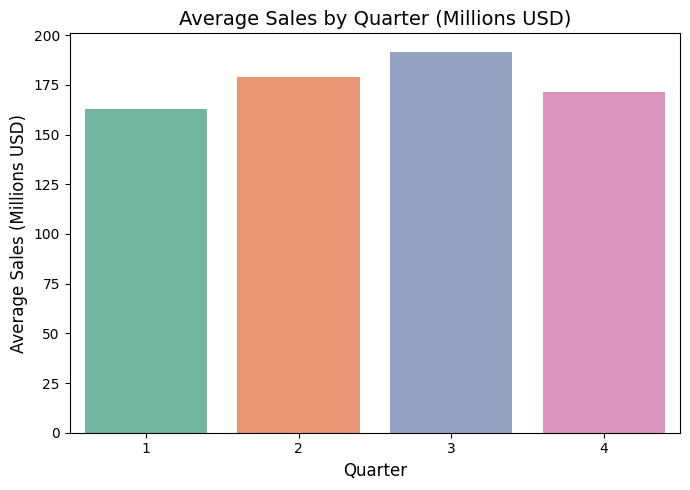

In [48]:
# --- Visualization 4: Sales by Quarter ---
quarterly_mean_sales = data.groupby('Quarter')['Sales'].mean() / 1e6 # Convert to Millions

plt.figure(figsize=(7, 5))
sns.barplot(x=quarterly_mean_sales.index, y=quarterly_mean_sales.values, palette='Set2')
plt.title('Average Sales by Quarter (Millions USD)', fontsize=14)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Average Sales (Millions USD)', fontsize=12)
plt.tight_layout()
plt.show()


<Figure size 1200x800 with 0 Axes>

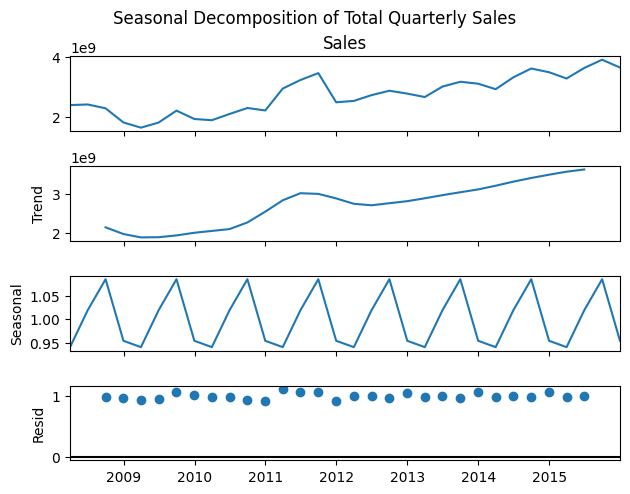

In [53]:
# Perform seasonal decomposition on total sales (using a 4-quarter period)
decomposition = seasonal_decompose(monthly_sales, model='multiplicative', period=4)
# Plotting the decomposition
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle('Seasonal Decomposition of Total Quarterly Sales', y=1.02)
plt.show()


In [56]:
# Fit an ARIMA model to the total sales data
# Note: A proper ARIMA analysis would require testing for stationarity and parameter tuning.
model = ARIMA(monthly_sales, order=(5, 1, 0))
model_fit = model.fit()
print("\n--- ARIMA Model Summary (Order 5,1,0) ---")
print(model_fit.summary())


--- ARIMA Model Summary (Order 5,1,0) ---
                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   32
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -647.227
Date:                Tue, 07 Oct 2025   AIC                           1306.454
Time:                        13:03:25   BIC                           1315.058
Sample:                    03-31-2008   HQIC                          1309.259
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0148      0.207     -0.072      0.943      -0.420       0.390
ar.L2         -0.1313      0.122     -1.075      0.283      -0.371       0.108
ar.L3    

In [57]:
# Make predictions for the next 4 quarters (1 year)
forecast_steps = 4
forecast = model_fit.forecast(steps=forecast_steps)


In [59]:
# Create a date range for the forecast
forecast_index = pd.date_range(start=monthly_sales.index[-1] + pd.Timedelta(days=1),periods=forecast_steps,freq='Q')


/tmp/ipython-input-3273851730.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=monthly_sales.index[-1] + pd.Timedelta(days=1),periods=forecast_steps,freq='Q')


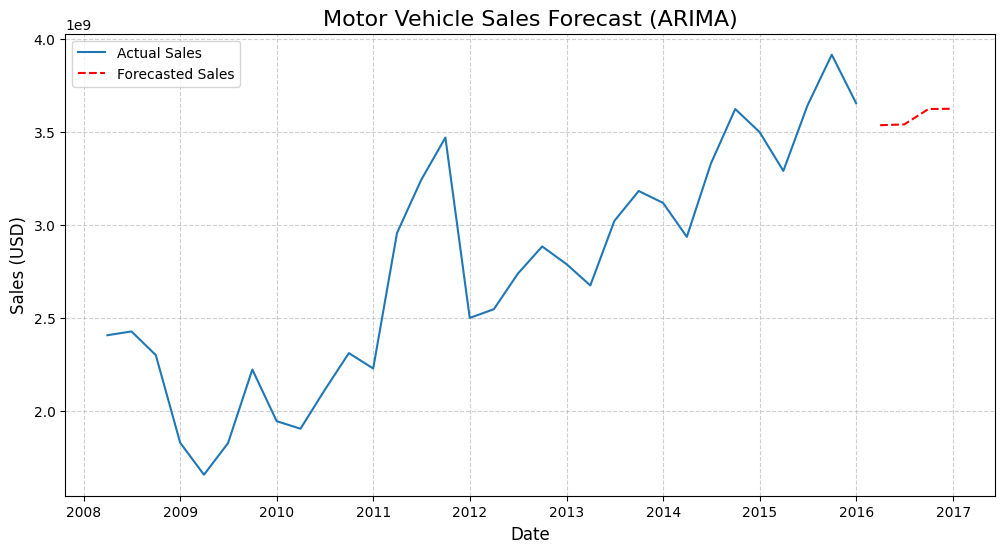

In [61]:
# Plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual Sales')
plt.plot(forecast_index, forecast, label='Forecasted Sales', color='red', linestyle='--')
plt.title('Motor Vehicle Sales Forecast (ARIMA)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [62]:
# 4. PREDICTIVE MODELING (RANDOM FOREST REGRESSOR)

# Prepare data for Machine Learning model
ml_data = data[['Year', 'Quarter', 'County', 'Sales']].copy()


In [63]:
# Encode the categorical 'County' column using Label Encoding (suitable for tree-based models)
le = LabelEncoder()
ml_data['County_Encoded'] = le.fit_transform(ml_data['County'])

In [64]:
# Define features (X) and target (y)
X = ml_data[['Year', 'Quarter', 'County_Encoded']]
y = ml_data['Sales']

In [65]:
# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Initialize and fit the Random Forest model (using 100 estimators as per PDF example)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [67]:
# Make predictions
y_pred = model.predict(X_test)

In [70]:
# Calculate RMSE and R2
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_test, y_test)

print(f"\n--- Random Forest Model Performance (Baseline) ---")
print(f"RMSE: {rmse:,.2f}")
print(f"R-squared: {r2:,.4f}")


--- Random Forest Model Performance (Baseline) ---
RMSE: 20,402,876.97
R-squared: 0.9842


/tmp/ipython-input-2020554641.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='coolwarm')


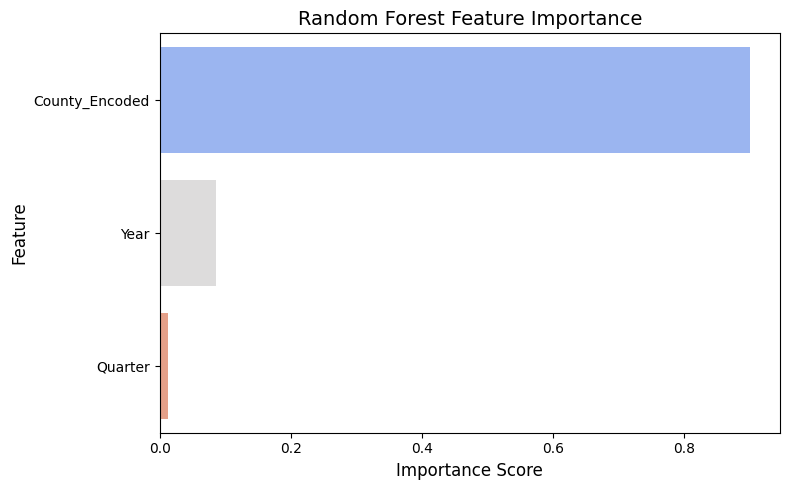

In [71]:
# --- Feature Importance ---
# Determine which features were most important in the prediction
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='coolwarm')
plt.title('Random Forest Feature Importance', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [72]:
# =================================================================
# 5. MODEL OPTIMIZATION (GRID SEARCH)
# =================================================================

# Use GridSearchCV to find the best hyperparameters

# Define the parameter grid
param_grid = {
 'n_estimators': [50, 100, 200],
 'max_depth': [10, 20],
 'min_samples_split': [5, 10]
}


In [76]:
# Initialize the model
model = RandomForestRegressor(random_state=42)

# Initialize the grid search
grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Fit the grid search
print("\n--- Running Grid Search for Hyperparameter Tuning... ---")
grid_search.fit(X_train, y_train)




--- Running Grid Search for Hyperparameter Tuning... ---


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'min_samples_split': [5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_root_mean_squared_error')

In [77]:
# Get the best parameters and score
best_params = grid_search.best_params_
best_score = np.sqrt(abs(grid_search.best_score_)) # Convert to positive RMSE

In [78]:
print(f"\nGrid Search Results:")
print(f"  - Best Parameters: {best_params}")
print(f"  - Best Model RMSE (Cross-Validation): {best_score:,.2f}")


Grid Search Results:
  - Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
  - Best Model RMSE (Cross-Validation): 5,581.19


In [79]:
# Final evaluation with the best estimator
final_model = grid_search.best_estimator_
y_pred_tuned = final_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
final_r2 = final_model.score(X_test, y_test)

print(f"  - Final Model RMSE (Test Set): {final_rmse:,.2f}")
print(f"  - Final Model R-squared (Test Set): {final_r2:,.4f}")

  - Final Model RMSE (Test Set): 23,799,708.49
  - Final Model R-squared (Test Set): 0.9785
